# Football Match Analysis — Player Detection, Tracking & Team Classification

**Coverage:** 6 Montenegro 1. CFL matches (March 2026)  
**Model:** YOLOv8n fine-tuned on 600 labeled frames (person, ball)

## Pipeline
1. **Detect** players and ball using fine-tuned YOLOv8n + ByteTrack
2. **Segment** each player with YOLOv8n-seg on the full frame to isolate foreground pixels
3. **Classify** teams via Lab median color from seg-masked jersey area + GMM clustering
4. **Annotate** with team-colored ellipses, ball triangles, and track IDs
5. **Export** annotated clips (minutes 10–15 per match, all 6 games)

In [1]:
import sys
import cv2
import numpy as np
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import importlib

# Ensure src is importable
sys.path.insert(0, str(Path.cwd()))

import src.config, src.video_utils, src.detection, src.team_classifier, src.tracking, src.visualization, src.segmentation
for mod in [src.config, src.video_utils, src.detection, src.team_classifier, src.tracking, src.visualization, src.segmentation]:
    importlib.reload(mod)

from src.config import Config
from src.video_utils import extract_clip, open_video, get_video_info, create_video_writer
from src.detection import PlayerDetector
from src.team_classifier import TeamClassifier
from src.tracking import Tracker
from src.visualization import Annotator
from src.segmentation import segment_frame, extract_player_mask, segment_player, extract_hsv_features, extract_lab_features

print("All modules loaded successfully.")

All modules loaded successfully.


In [2]:
# Load primary match video (used for detection preview & cluster visualization below)
clip_path = Config.FULL_MATCH_VIDEO
cap = open_video(clip_path)
info = get_video_info(cap)
cap.release()
print(f"{clip_path.name}: {info['width']}x{info['height']} @ {info['fps']}fps, {info['total_frames']} frames")

BUDUCNOST - SUTJESKA 1.CFL 20.KOLO 21.02.2026. CIJELA UTAKMICA.mp4: 1920x1080 @ 25.0fps, 169725 frames


## 1. Detection Preview

Players detected: 22
Ball detected: 1


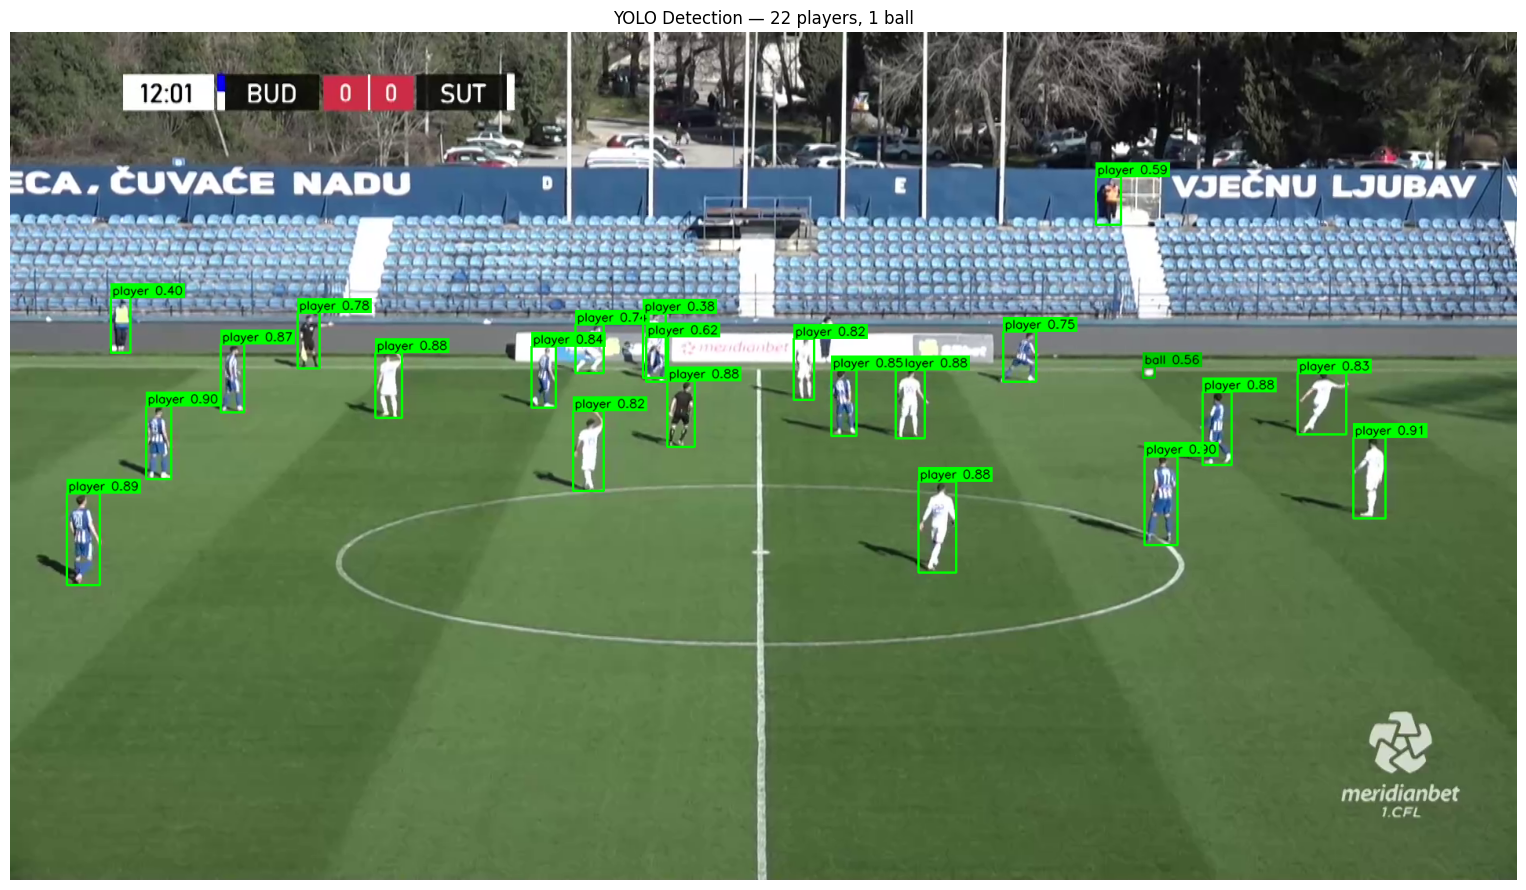

In [3]:
detector = PlayerDetector()

cap = open_video(clip_path)
# Skip ahead 30 seconds to get a good gameplay frame
cap.set(cv2.CAP_PROP_POS_FRAMES, int(info['fps'] * 1000))
ret, frame = cap.read()
cap.release()

detections = detector.detect(frame)
print(f"Players detected: {len(detections['players'])}")
print(f"Ball detected: {len(detections['ball'])}")

# Show debug annotation
annotator = Annotator()
debug_frame = annotator.annotate_frame_debug(frame, detections)

plt.figure(figsize=(16, 9))
plt.imshow(cv2.cvtColor(debug_frame, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f'YOLO Detection — {len(detections["players"])} players, {len(detections["ball"])} ball')
plt.tight_layout()
plt.show()

### Segmentation Crop Inspector

For each detected player, show the raw crop, segmentation mask, and masked result side by side.

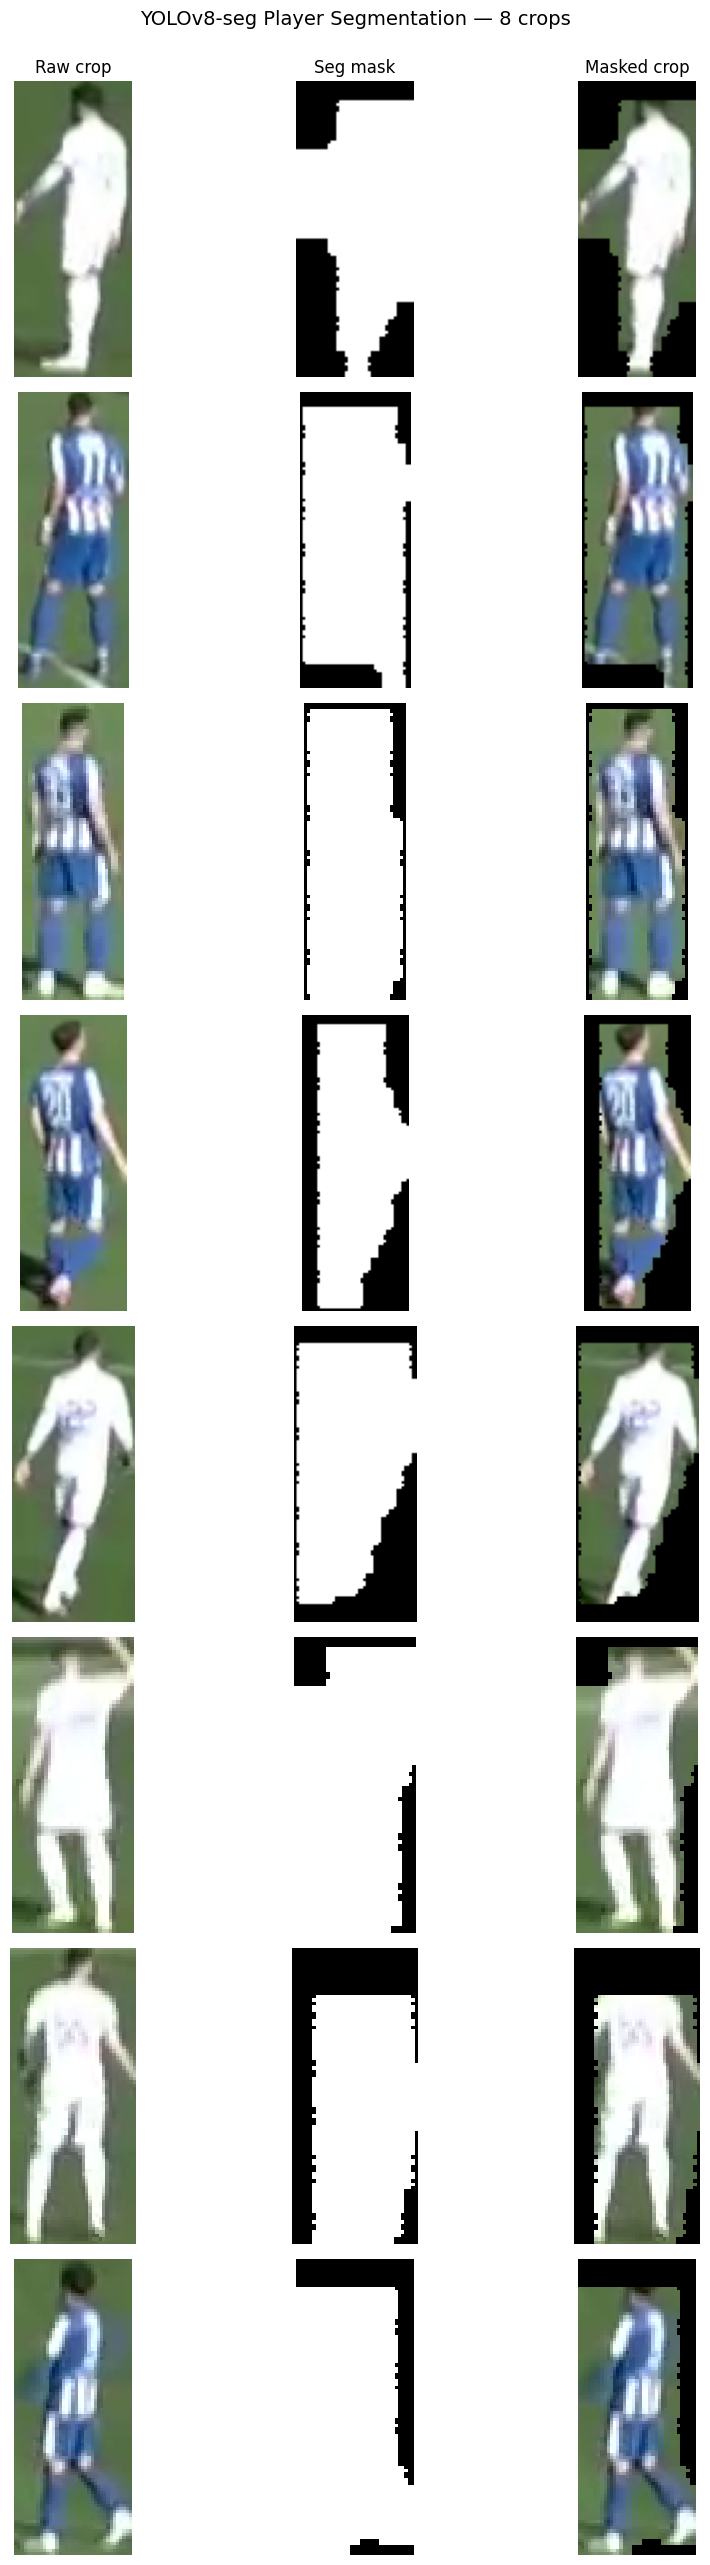

In [4]:
from ultralytics import YOLO

seg_model = YOLO(Config.YOLO_SEG_MODEL)

# Run segmentation ONCE on the full frame (model needs full-person silhouettes)
frame_mask = segment_frame(frame, seg_model)

# Use up to 8 detected players from the preview frame
players = detections['players'][:8]
n = len(players)

fig, axes = plt.subplots(n, 3, figsize=(10, 3.2 * n))
if n == 1:
    axes = axes[np.newaxis, :]  # ensure 2D indexing

for row, p in enumerate(players):
    x1, y1, x2, y2 = p['bbox']
    raw_crop = frame[y1:y2, x1:x2]

    # Slice this player's mask from the full-frame mask
    masked_crop, mask = extract_player_mask(frame, p['bbox'], frame_mask)

    # Column 0 — raw crop
    axes[row, 0].imshow(cv2.cvtColor(raw_crop, cv2.COLOR_BGR2RGB))
    axes[row, 0].set_title('Raw crop' if row == 0 else '')
    axes[row, 0].axis('off')

    # Column 1 — binary mask
    axes[row, 1].imshow(mask, cmap='gray', vmin=0, vmax=255)
    axes[row, 1].set_title('Seg mask' if row == 0 else '')
    axes[row, 1].axis('off')

    # Column 2 — masked crop (background zeroed)
    axes[row, 2].imshow(cv2.cvtColor(masked_crop, cv2.COLOR_BGR2RGB))
    axes[row, 2].set_title('Masked crop' if row == 0 else '')
    axes[row, 2].axis('off')

plt.suptitle(f'YOLOv8-seg Player Segmentation — {n} crops', fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

## 2. Jersey Color Embedding Collection

Sample every N-th frame from the 10:00–15:00 window to collect seg-masked Lab median color features for GMM clustering.

In [5]:
team_clf = TeamClassifier()
all_embeddings = []

SAMPLE_EVERY_N = 15        # sample every 15th frame
EMBED_START_SEC = 10 * 60  # 10:00 — same window as batch annotation
EMBED_END_SEC   = 15 * 60  # 15:00

cap = open_video(clip_path)
fps   = cap.get(cv2.CAP_PROP_FPS)
start = int(fps * EMBED_START_SEC)
end   = int(fps * EMBED_END_SEC)
clip_frames = end - start

cap.set(cv2.CAP_PROP_POS_FRAMES, start)
print(f"Collecting seg-masked Lab colors from {clip_frames // SAMPLE_EVERY_N} frames "
      f"({EMBED_START_SEC // 60}:00 – {EMBED_END_SEC // 60}:00)...")

for i in tqdm(range(clip_frames), desc="Extracting embeddings"):
    ret, frame = cap.read()
    if not ret:
        break
    if i % SAMPLE_EVERY_N == 0:
        detections = detector.detect(frame)
        embs = team_clf.collect_embeddings(frame, detections['players'])
        all_embeddings.extend(embs)

cap.release()
all_embeddings = np.array(all_embeddings)
print(f"\nCollected {len(all_embeddings)} embeddings ({all_embeddings.shape[1]}-dim each)")

TeamClassifier: seg-masked Lab median (3-dim, k=2 GMM + conf-gate referee)


Extracting embeddings: 100%|██████████| 7500/7500 [01:08<00:00, 109.08it/s]


Collected 7101 embeddings (3-dim each)


## 3. Fit & Visualize Team Clusters

In [6]:
team_clf.fit(all_embeddings)

# Features are 3-dim Lab (L, a, b) — no PCA needed
labels = [team_clf.predict(e) for e in all_embeddings]
print(f"\nVisualization ready — {len(all_embeddings)} samples in Lab color space (L, a, b)")

Team classification fitted on 6966 seg-masked Lab colors (3-dim)
  GMM weights  : Team A=52.1%, Team B=47.9%
  Cluster sizes: Team A=3684, Team B=3282
  Outliers (conf < 75%): ~776 (11.1%) → classified as Referee/GK

Visualization ready — 7101 samples in Lab color space (L, a, b)


### Interactive Cluster Explorer

Hover over points to see the jersey crop that produced each color sample.

In [7]:
import plotly.graph_objects as go
import base64, io
from PIL import Image
import ipywidgets as widgets
from IPython.display import display

# --- Collect embeddings + thumbnail crops ---
viz_embeddings = []
crop_images_b64 = []
THUMB_W, THUMB_H = 48, 72
INTERACTIVE_SAMPLE_EVERY = 45

cap = open_video(clip_path)
fps_viz   = cap.get(cv2.CAP_PROP_FPS)
start_viz = int(fps_viz * EMBED_START_SEC)
end_viz   = int(fps_viz * EMBED_END_SEC)
clip_viz  = end_viz - start_viz

cap.set(cv2.CAP_PROP_POS_FRAMES, start_viz)
print(f"Collecting crops + embeddings from ~{clip_viz // INTERACTIVE_SAMPLE_EVERY} frames "
      f"({EMBED_START_SEC // 60}:00 – {EMBED_END_SEC // 60}:00)...")

for i in tqdm(range(clip_viz), desc="Collecting"):
    ret, frame = cap.read()
    if not ret:
        break

    if i % INTERACTIVE_SAMPLE_EVERY == 0:
        dets = detector.detect(frame)
        if dets['players']:
            bboxes = [p['bbox'] for p in dets['players']]
            embs = team_clf.extract_embeddings_batch(frame, bboxes)
            viz_embeddings.extend(embs)

            for p in dets['players']:
                x1, y1, x2, y2 = p['bbox']
                crop = frame[y1:y2, x1:x2]
                if crop.size == 0:
                    crop_images_b64.append("")
                    continue
                crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
                pil_img = Image.fromarray(crop_rgb).resize((THUMB_W, THUMB_H), Image.LANCZOS)
                buf = io.BytesIO()
                pil_img.save(buf, format='PNG')
                crop_images_b64.append(base64.b64encode(buf.getvalue()).decode('utf-8'))

cap.release()
viz_embeddings = np.array(viz_embeddings)
print(f"Collected {len(viz_embeddings)} samples with crops")

# Lab features are 3-dim — use directly as 3D plot coordinates (no PCA)
viz_3d = viz_embeddings  # columns: [L, a, b]
pred_team_ids = [team_clf.predict(e) for e in viz_embeddings]
team_names_map = {0: 'Team A', 1: 'Team B', 2: 'Referee / GK'}
team_hex = {0: '#3498db', 1: '#f1c40f', 2: '#e74c3c'}

# --- Plotly FigureWidget with hover crop preview ---
fig = go.FigureWidget()

for tid, tname in team_names_map.items():
    mask = [i for i, t in enumerate(pred_team_ids) if t == tid]
    if not mask:
        continue
    fig.add_trace(go.Scatter3d(
        x=viz_3d[mask, 0],
        y=viz_3d[mask, 1],
        z=viz_3d[mask, 2],
        mode='markers',
        marker=dict(size=2, color=team_hex[tid], opacity=0.6),
        name=tname,
        customdata=mask,
        hovertemplate=(
            f'<b>{tname}</b><br>'
            'L=%{x:.0f}<br>a=%{y:.0f}<br>b=%{z:.0f}'
            '<extra></extra>'
        ),
    ))

fig.update_layout(
    title='3D Team Clusters — Seg-Masked Lab Median Color + GMM',
    scene=dict(
        xaxis_title='L (lightness)',
        yaxis_title='a  (green ↔ red)',
        zaxis_title='b  (blue ↔ yellow)',
    ),
    width=800, height=650,
    margin=dict(l=0, r=0, t=40, b=0),
)

# --- Hover image panel ---
crop_widget = widgets.Image(format='png', width=96, height=144,
                            layout=widgets.Layout(border='1px solid #ccc'))
label_widget = widgets.HTML(value='<i>Hover over a point to see the player crop</i>')

_blank = Image.new('RGB', (THUMB_W, THUMB_H), (220, 220, 220))
_buf = io.BytesIO()
_blank.save(_buf, format='PNG')
crop_widget.value = _buf.getvalue()

def make_hover_handler():
    def handler(trace, points, state):
        if points.point_inds:
            local_idx = points.point_inds[0]
            if trace.customdata is not None:
                global_idx = int(trace.customdata[local_idx])
                if 0 <= global_idx < len(crop_images_b64) and crop_images_b64[global_idx]:
                    crop_widget.value = base64.b64decode(crop_images_b64[global_idx])
                    label_widget.value = f'<b>{trace.name}</b> — sample #{global_idx}'
    return handler

_handler = make_hover_handler()
for trace in fig.data:
    if hasattr(trace, 'customdata') and trace.customdata is not None:
        trace.on_hover(_handler)

display(widgets.HBox([
    fig,
    widgets.VBox([label_widget, crop_widget],
                 layout=widgets.Layout(padding='20px', align_items='center',
                                       justify_content='center'))
]))

Collecting: 100%|██████████| 7500/7500 [00:38<00:00, 193.24it/s]


Collected 2369 samples with crops


    'data': [{'customdata': [0, 3, 6, ..., 2362, 2363, 2366],
              'hov…

## Known Issues & Next Steps

### Current limitations
- **Ball detection** — Poor on wide-angle shots (ball is ~15 px, motion-blurred). Works on close-ups only. Consider TrackNet or temporal interpolation.
- **Team classification** — Seg-masked Lab median handles white-vs-blue well but may degrade in heavy shadow or when both teams wear near-identical colors. Segmentation adds latency (~1 seg inference per frame).
- **Track ID switches** — ByteTrack loses IDs during close player interactions. Appearance-based ReID (BoT-SORT) would help.

### Next steps
- Improve ball detection (TrackNet / lower confidence threshold + interpolation)
- Improve team classification (contrastive learning / supervised approach)
- Homography estimation — map pixel → pitch coordinates
- Player speed & distance from pitch coordinates
- Scale to full match and league (GPU)

## 4. Batch Annotation — All 6 Games (10:00 → 15:00)

Runs the full pipeline (detect → classify teams → track → annotate) on minutes 10–15 of every configured match using the current best model.

Each game gets its own fresh `TeamClassifier` fit — teams wear different kits across matches so a single global GMM would be wrong.

**Output:** `output/{slug}_5min.mp4` per game.

In [ ]:
# Reload src modules — picks up any source edits since the setup cell ran
import importlib
import src.config, src.detection, src.team_classifier, src.tracking, src.visualization, src.video_utils, src.segmentation
for mod in [src.config, src.detection, src.team_classifier, src.tracking, src.visualization, src.video_utils, src.segmentation]:
    importlib.reload(mod)

from src.config import Config
from src.detection import PlayerDetector
from src.team_classifier import TeamClassifier
from src.tracking import Tracker
from src.visualization import Annotator
from src.video_utils import create_video_writer

CLIP_START_SEC = 10 * 60   # 10:00
CLIP_END_SEC   = 15 * 60   # 15:00
SAMPLE_EVERY_N = 15         # frames to skip between embedding samples

# All 6 games — Budućnost-Sutjeska is included as game 1
GAMES = [
    {"path": Config.FULL_MATCH_VIDEO, "slug": "bud-sut"},
    *[{"path": Path(str(e["path"])), "slug": e["slug"]} for e in Config.BALL_ANNOTATION_VIDEOS],
]

Config.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
annotator = Annotator()

for game in GAMES:
    video_path = Path(str(game["path"]))
    slug       = game["slug"]
    output_path = Config.OUTPUT_DIR / f"{slug}_5min.mp4"

    print(f"\n{'─' * 60}")
    print(f"Game : {video_path.name}")

    if not video_path.exists():
        print(f"  SKIP — video not found")
        continue

    if output_path.exists():
        print(f"  SKIP — output already exists: {output_path.name}")
        continue

    cap = cv2.VideoCapture(str(video_path))
    fps          = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width        = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height       = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    start_frame = int(fps * CLIP_START_SEC)
    end_frame   = min(int(fps * CLIP_END_SEC), total_frames - 1)
    clip_frames = end_frame - start_frame

    if clip_frames <= 0:
        print(f"  SKIP — video shorter than {CLIP_START_SEC // 60} minutes")
        cap.release()
        continue

    print(f"  Clip : {CLIP_START_SEC // 60}:00 → {CLIP_END_SEC // 60}:00  ({clip_frames} frames @ {fps:.1f} fps)")

    # Fresh instances per game — resets tracker state and fits a new GMM
    detector  = PlayerDetector()
    game_clf  = TeamClassifier()
    tracker   = Tracker()

    # ── Pass 1: collect embeddings to fit team classifier ──────────────────
    all_embeddings = []
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
    for i in tqdm(range(clip_frames), desc=f"  {slug} — embeddings", leave=False):
        ret, frame = cap.read()
        if not ret:
            break
        if i % SAMPLE_EVERY_N == 0:
            dets = detector.detect(frame)
            embs = game_clf.collect_embeddings(frame, dets["players"])
            all_embeddings.extend(embs)

    if not all_embeddings:
        print(f"  SKIP — no player detections in this clip")
        cap.release()
        continue

    game_clf.fit(np.array(all_embeddings))

    # ── Pass 2: detect + track + classify + annotate ───────────────────────
    writer = create_video_writer(output_path, fps, width, height)
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
    for _ in tqdm(range(clip_frames), desc=f"  {slug} — annotating"):
        ret, frame = cap.read()
        if not ret:
            break

        dets = detector.detect_with_tracking(frame)
        game_clf.classify_players(frame, dets["players"])
        for p in dets["players"]:
            p["team_id"] = tracker.get_stable_team(p["track_id"], p["team_id"])

        annotated = annotator.annotate_frame(frame, dets)
        writer.write(annotated)

    writer.release()
    cap.release()

    size_mb = output_path.stat().st_size / 1e6
    print(f"  Saved : {output_path.name}  ({size_mb:.1f} MB)")
    print(f"  Tracks: {len(tracker.track_team_history)}")

print(f"\n{'═' * 60}")
print("Batch annotation complete.")
print(f"Output directory: {Config.OUTPUT_DIR}")


────────────────────────────────────────────────────────────
Game : BUDUCNOST - SUTJESKA 1.CFL 20.KOLO 21.02.2026. CIJELA UTAKMICA.mp4
  Clip : 10:00 → 15:00  (7500 frames @ 25.0 fps)
TeamClassifier: seg-masked Lab median (3-dim, k=2 GMM + conf-gate referee)


Team classification fitted on 6966 seg-masked Lab colors (3-dim)
  GMM weights  : Team A=52.1%, Team B=47.9%
  Cluster sizes: Team A=3684, Team B=3282
  Outliers (conf < 75%): ~776 (11.1%) → classified as Referee/GK


  bud-sut — annotating: 100%|██████████| 7500/7500 [12:00<00:00, 10.42it/s]


  Saved : bud-sut_5min.mp4  (462.4 MB)
  Tracks: 913

────────────────────────────────────────────────────────────
Game : ARSENAL - DECIC 1.CFL 21.03.2026. CIJELA UTAKMICA.mp4
  Clip : 10:00 → 15:00  (7500 frames @ 25.0 fps)
TeamClassifier: seg-masked Lab median (3-dim, k=2 GMM + conf-gate referee)


Team classification fitted on 4728 seg-masked Lab colors (3-dim)
  GMM weights  : Team A=79.2%, Team B=20.8%
  Cluster sizes: Team A=3834, Team B=894
  Outliers (conf < 75%): ~235 (5.0%) → classified as Referee/GK


...

Team classification fitted on 5554 seg-masked Lab colors (3-dim)
  GMM weights  : Team A=85.0%, Team B=15.0%
  Cluster sizes: Team A=4807, Team B=747
  Outliers (conf < 75%): ~201 (3.6%) → classified as Referee/GK


  pet-mor — annotating: 100%|██████████| 7500/7500 [09:41<00:00, 12.90it/s]


  Saved : pet-mor_5min.mp4  (365.5 MB)
  Tracks: 1298

────────────────────────────────────────────────────────────
Game : SUTJESKA - MLADOST 1.CFL 21.03.2026. CIJELA UTAKMICA.mp4
  Clip : 10:00 → 15:00  (7500 frames @ 25.0 fps)
TeamClassifier: seg-masked Lab median (3-dim, k=2 GMM + conf-gate referee)


Team classification fitted on 6167 seg-masked Lab colors (3-dim)
  GMM weights  : Team A=58.0%, Team B=42.0%
  Cluster sizes: Team A=3564, Team B=2603
  Outliers (conf < 75%): ~84 (1.4%) → classified as Referee/GK


  sut-mla — annotating:  10%|▉         | 748/7500 [01:25<12:04,  9.32it/s]